<a href="https://colab.research.google.com/github/rlaharira/DeepFER/blob/main/DeepFER_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Name
DeepFer – DeepFake Detection System

# Project Summary
DeepFer is a deep learning-based system that detects whether an image or video is authentic or a deepfake using TensorFlow and computer vision techniques.

# GitHub Link
https://github.com/rlaharira/FSWD/blob/main/DeepFER_project.ipynb

# Problem Statement
The increasing use of AI-generated media has made it difficult to distinguish real content from manipulated content. This project aims to accurately detect deepfake images and videos using deep learning.

# General Guidelines
- Run the notebook from top to bottom.
- Enable GPU runtime.
- Upload the dataset ZIP file when prompted.
- Wait for dataset extraction before training or testing.

# 1. Import Libraries

In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive-3 (1).zip to archive-3 (1).zip


# 3. Extract Dataset

In [ ]:
import zipfile
import os

zip_path = "archive-3 (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("✅ Dataset extracted successfully!")
print(os.listdir("dataset"))

✅ Dataset extracted successfully!
['__MACOSX', 'archive-3']


# 4. Data Preprocessing

In [ ]:
import os

print(os.listdir("dataset/archive-3"))

['test', 'train']


In [ ]:
import os

for root, dirs, files in os.walk("dataset/archive-3"):
    print(root)

dataset/archive-3
dataset/archive-3/test
dataset/archive-3/test/neutral
dataset/archive-3/test/sad
dataset/archive-3/test/surprise
dataset/archive-3/test/fear
dataset/archive-3/test/angry
dataset/archive-3/test/disgust
dataset/archive-3/test/happy
dataset/archive-3/train
dataset/archive-3/train/neutral
dataset/archive-3/train/sad
dataset/archive-3/train/surprise
dataset/archive-3/train/fear
dataset/archive-3/train/angry
dataset/archive-3/train/disgust
dataset/archive-3/train/happy


In [ ]:
import os

train_path = None
test_path = None

for root, dirs, files in os.walk("dataset/archive-3"):
    if "train" in dirs:
        train_path = os.path.join(root, "train")
    if "test" in dirs:
        test_path = os.path.join(root, "test")

print("Train Path:", train_path)
print("Test Path:", test_path)

Train Path: dataset/archive-3/train
Test Path: dataset/archive-3/test


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "dataset/archive-3/train",
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    "dataset/archive-3/test",
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical"
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# 5. CNN Model Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(7, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,015 (2.36 MB)

 Trainable params: 619,015 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

# 6. Model Training

In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.2861 - loss: 1.7432 - val_accuracy: 0.4046 - val_loss: 1.5462
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.3903 - loss: 1.5588 - val_accuracy: 0.4561 - val_loss: 1.4138
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.4372 - loss: 1.4548 - val_accuracy: 0.4937 - val_loss: 1.3319
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.4710 - loss: 1.3890 - val_accuracy: 0.5159 - val_loss: 1.2656
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.4880 - loss: 1.3393 - val_accuracy: 0.5295 - val_loss: 1.2331
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.5017 - loss: 1.3127 - val_accuracy: 0.5393 - val_loss: 1.2111
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.5103 - loss: 1.2898 - val_accuracy: 0.5313 - val_loss: 1.2202
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.5186 - loss: 1.2698 - 

# 7. Model Saving

In [ ]:
model.save("DeepFER_Model.keras")
print("✅ Model saved successfully!")

✅ Model saved successfully!


# 8. Model Evaluation

In [ ]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy * 100, "%")

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5424 - loss: 1.1865
Test Loss: 1.1865156888961792
Test Accuracy: 54.23516035079956 %


# 9. Accuracy and Loss Graphs

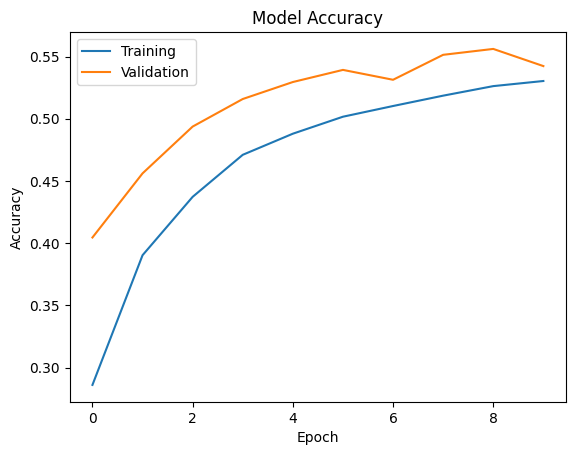

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])

plt.show()

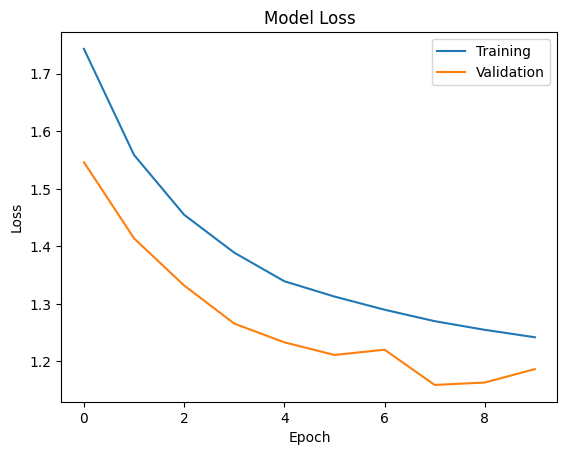

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training", "Validation"])

plt.show()

In [ ]:
from google.colab import files
files.download("DeepFER_Model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#  10. Emotion Prediction

In [ ]:
import os

happy_path = "dataset/archive-3/test/happy"

print(os.listdir(happy_path)[:5])

['PrivateTest_44181357.jpg', 'PublicTest_58836396.jpg', 'PublicTest_13277039.jpg', 'PublicTest_24056456.jpg', 'PrivateTest_40317032.jpg']


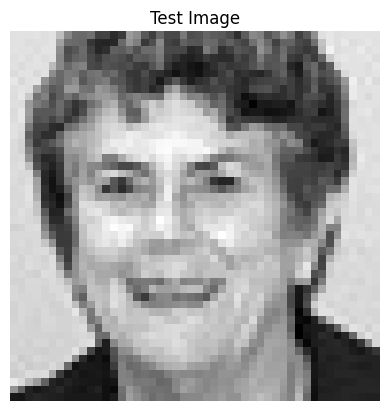

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 925ms/step
Predicted Emotion: Happy
Prediction Probabilities: [[8.8418759e-03 1.9739742e-05 1.9210677e-03 9.4528294e-01 3.8298510e-02
  1.2803143e-03 4.3555372e-03]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Path to the image
img_path = "dataset/archive-3/test/happy/PrivateTest_44181357.jpg"

# Load image
img = image.load_img(img_path, target_size=(48,48), color_mode="grayscale")

# Display image
plt.imshow(img, cmap="gray")
plt.title("Test Image")
plt.axis("off")
plt.show()

# Preprocess image
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

predicted_emotion = emotion_labels[np.argmax(prediction)]

print("Predicted Emotion:", predicted_emotion)
print("Prediction Probabilities:", prediction)

225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step


<Figure size 800x800 with 0 Axes>

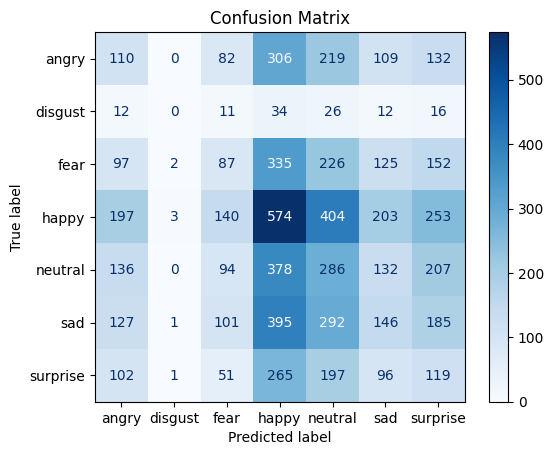

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true labels
y_true = test_generator.classes

# Predict all test images
test_generator.reset()
predictions = model.predict(test_generator)

# Get predicted labels
y_pred = np.argmax(predictions, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display it
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(test_generator.class_indices.keys())
)

plt.figure(figsize=(8,8))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

              precision    recall  f1-score   support

       angry       0.14      0.11      0.13       958
     disgust       0.00      0.00      0.00       111
        fear       0.15      0.08      0.11      1024
       happy       0.25      0.32      0.28      1774
     neutral       0.17      0.23      0.20      1233
         sad       0.18      0.12      0.14      1247
    surprise       0.11      0.14      0.13       831

    accuracy                           0.18      7178
   macro avg       0.14      0.15      0.14      7178
weighted avg       0.18      0.18      0.18      7178

